In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from broadcasting.results import load_run, list_runs

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120})

RESULTS_DIR = Path("results")


def latest_run():
    files = sorted(RESULTS_DIR.glob("run_*.json"))
    if not files:
        raise FileNotFoundError("No run files found in results/")
    return load_run(files[-1])


def get_p_list(run):
    """Extract noise values from a run dict."""
    # New simulation format stores p_list in metadata
    p = run.get("metadata", {}).get("p_list") or run.get("p_list")
    if p is None:
        raise KeyError("No p_list found in run — is this a hardware (tau-sweep) result?")
    return np.array(p)


runs = list_runs(RESULTS_DIR)
print(f"Found {len(runs)} run(s) in {RESULTS_DIR}/\n")
for i, r in enumerate(runs):
    qec_str = "QEC" if r.get("use_qec") else "no-QEC"
    mode = r.get("metadata", {}).get("mode", r.get("backend", "?"))
    n_fids = len(r.get("fidelities", []))
    N = r["N"]
    print(f"  [{i}] {r['filename']}: M={r['M']}, N={N}, {qec_str}, "
          f"mode={mode}, {n_fids} noise points")


Found 8 run(s) in results/

  [0] run_20260416_100341.json: M=1, N=2, QEC, mode=sampled (1000 trajectories), 50 noise points
  [1] run_20260422_110316.json: M=1, N=2, no-QEC, mode=exact, 5 noise points
  [2] run_20260422_112803.json: M=2, N=1, QEC, mode=exact, 50 noise points
  [3] run_20260422_112804.json: M=3, N=1, QEC, mode=exact, 50 noise points
  [4] run_20260422_112808.json: M=4, N=1, QEC, mode=exact, 50 noise points
  [5] run_20260422_113320.json: M=4, N=2, QEC, mode=sampled (1000 trajectories), 50 noise points
  [6] run_20260422_113612.json: M=1, N=2, QEC, mode=exact, 50 noise points
  [7] run_20260422_113619.json: M=1, N=3, QEC, mode=sampled (1000 trajectories), 50 noise points


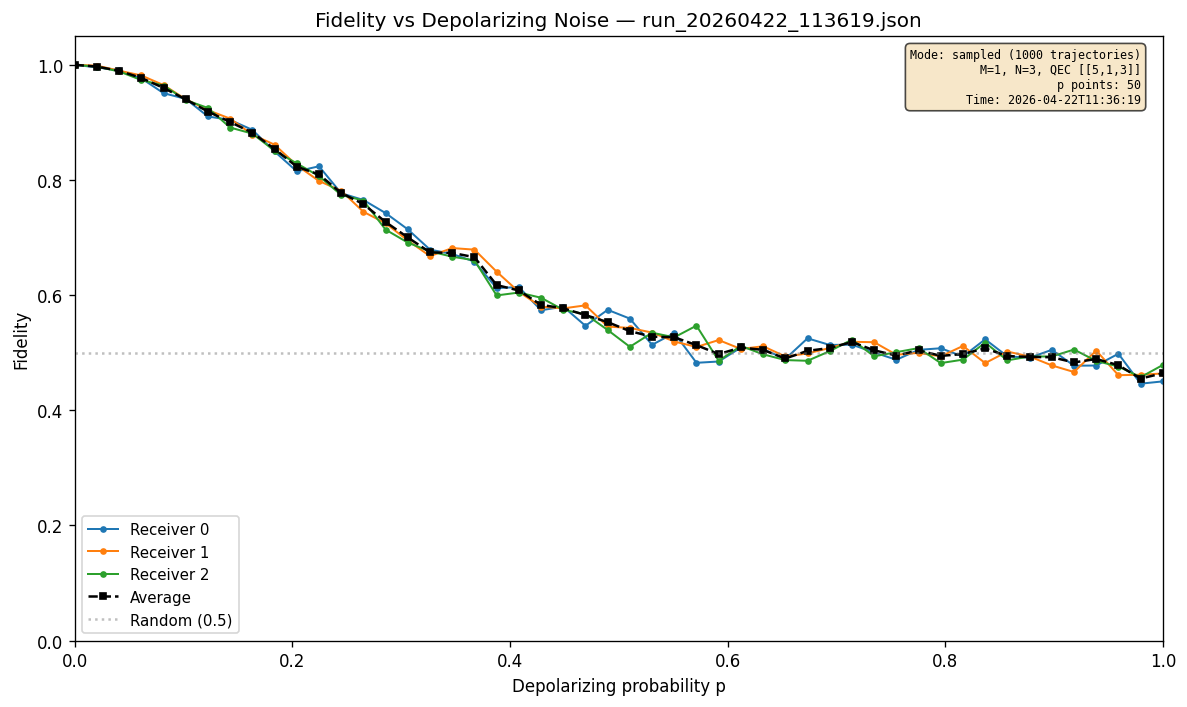

In [4]:
# --- Latest run: fidelity vs noise ---

run = latest_run()
N = run["N"]
fids = np.array(run["fidelities"])  # shape (n_p, N)
p_arr = get_p_list(run)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab10.colors

for i in range(N):
    ax.plot(p_arr, fids[:, i], "-o", color=colors[i % len(colors)],
            markersize=3, linewidth=1.2, label=f"Receiver {i}")

ax.plot(p_arr, fids.mean(axis=1), "s--", color="black",
        markersize=4, linewidth=1.5, label="Average")
ax.axhline(0.5, color="gray", linestyle=":", alpha=0.5, label="Random (0.5)")

ax.set_xlabel("Depolarizing probability p")
ax.set_ylabel("Fidelity")
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 1)
ax.legend(loc="best", fontsize=9)

# Metadata annotation
meta = run.get("metadata", {})
qec_str = "QEC [[5,1,3]]" if run.get("use_qec") else "No QEC"
mode = meta.get("mode", run.get("backend", "?"))
meta_lines = [
    f"Mode: {mode}",
    f"M={run['M']}, N={N}, {qec_str}",
    f"p points: {len(p_arr)}",
    f"Time: {run.get('timestamp', '')[:19]}",
]
ax.text(0.98, 0.98, "\n".join(meta_lines), transform=ax.transAxes,
        fontsize=7, va="top", ha="right", fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="wheat", alpha=0.7))

ax.set_title(f"Fidelity vs Depolarizing Noise — {run['filename']}")
plt.tight_layout()
plt.show()


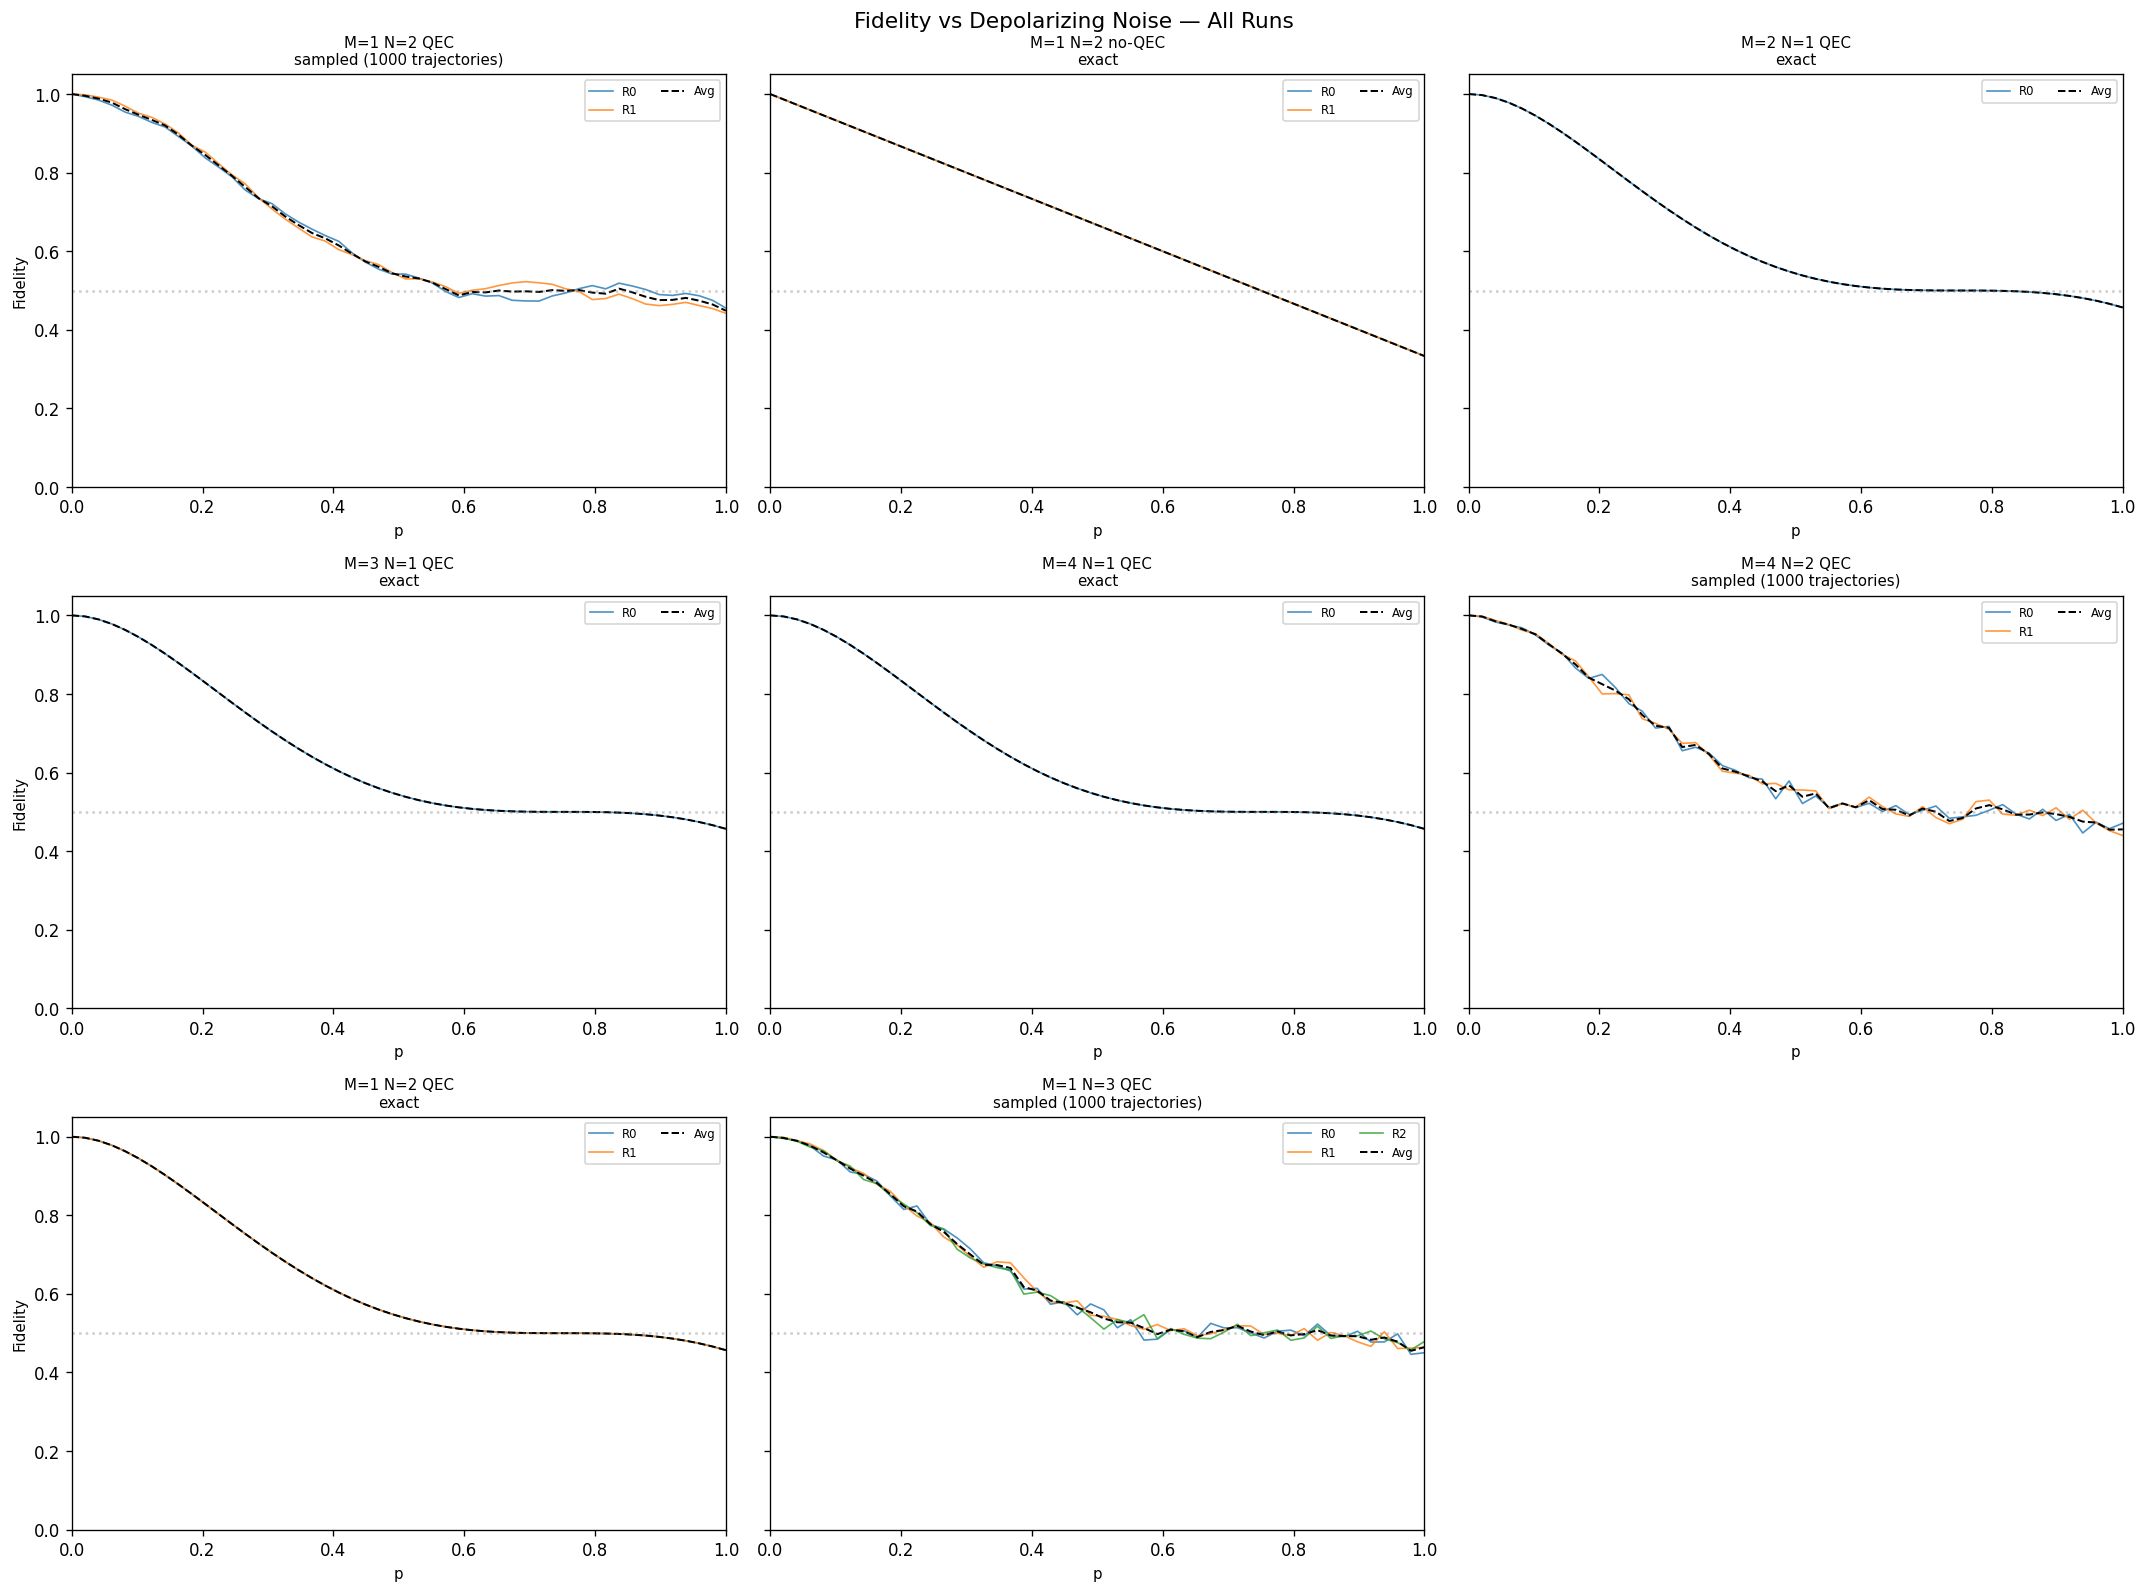


8 run(s) shown:
  [0] run_20260416_100341.json  M=1 N=2 QEC  sampled (1000 trajectories)
  [1] run_20260422_110316.json  M=1 N=2 no-QEC  exact
  [2] run_20260422_112803.json  M=2 N=1 QEC  exact
  [3] run_20260422_112804.json  M=3 N=1 QEC  exact
  [4] run_20260422_112808.json  M=4 N=1 QEC  exact
  [5] run_20260422_113320.json  M=4 N=2 QEC  sampled (1000 trajectories)
  [6] run_20260422_113612.json  M=1 N=2 QEC  exact
  [7] run_20260422_113619.json  M=1 N=3 QEC  sampled (1000 trajectories)


In [5]:
# --- Multi-run comparison: fidelity vs noise ---
# Customize the filter below to select which runs to compare.
# Examples:
#   selected = runs                                      # all runs
#   selected = [runs[0], runs[2]]                        # by index
#   selected = [r for r in runs if r["use_qec"]]         # QEC only
#   selected = [r for r in runs if r["M"] == 1]          # M=1 only
#   selected = [r for r in runs if r["N"] == 2]          # N=2 only

selected = runs  # all runs

if not selected:
    print("No runs matched the selection criteria.")
else:
    n_runs = len(selected)
    ncols = min(n_runs, 3)
    nrows = int(np.ceil(n_runs / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows),
                             squeeze=False, sharey=True)

    for idx, run in enumerate(selected):
        ax = axes[idx // ncols][idx % ncols]
        try:
            p_arr = get_p_list(run)
        except KeyError:
            ax.text(0.5, 0.5, "No p_list\n(hardware run?)", ha="center",
                    va="center", transform=ax.transAxes)
            continue

        fids = np.array(run["fidelities"])  # (n_p, N)
        N = run["N"]
        colors = plt.cm.tab10.colors

        for i in range(N):
            ax.plot(p_arr, fids[:, i], "-", color=colors[i % len(colors)],
                    linewidth=1, alpha=0.8, label=f"R{i}")
        ax.plot(p_arr, fids.mean(axis=1), "k--", linewidth=1.2, label="Avg")
        ax.axhline(0.5, color="gray", linestyle=":", alpha=0.4)
        ax.set_ylim(0, 1.05)
        ax.set_xlim(0, 1)
        ax.set_xlabel("p", fontsize=9)
        if idx % ncols == 0:
            ax.set_ylabel("Fidelity", fontsize=9)
        ax.legend(fontsize=7, loc="upper right", ncol=2)

        qec_tag = "QEC" if run.get("use_qec") else "no-QEC"
        mode = run.get("metadata", {}).get("mode", "?")
        ax.set_title(f"M={run['M']} N={N} {qec_tag}\n{mode}", fontsize=9)

    for idx in range(n_runs, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle("Fidelity vs Depolarizing Noise — All Runs", fontsize=13)
    plt.tight_layout()
    plt.show()

    print(f"\n{n_runs} run(s) shown:")
    for i, r in enumerate(selected):
        print(f"  [{i}] {r['filename']}  M={r['M']} N={r['N']} "
              f"{'QEC' if r.get('use_qec') else 'no-QEC'}  "
              f"{r.get('metadata', {}).get('mode', '?')}")


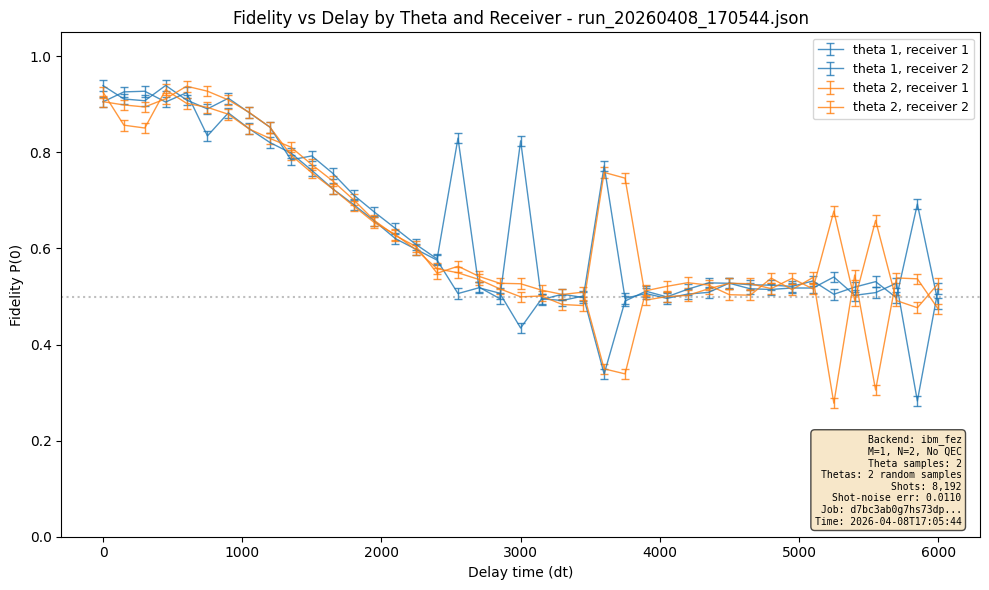

In [ ]:
# --- QEC vs no-QEC overlay: same M, N across runs ---
# Compares runs that share the same (M, N) but differ in use_qec or mode.

# Group runs by (M, N)
from itertools import groupby
from collections import defaultdict

groups = defaultdict(list)
for r in runs:
    groups[(r["M"], r["N"])].append(r)

pairs = {k: v for k, v in groups.items() if len(v) >= 1}

if not pairs:
    print("No runs to compare.")
else:
    n_groups = len(pairs)
    ncols = min(n_groups, 3)
    nrows = int(np.ceil(n_groups / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows),
                             squeeze=False, sharey=True)

    linestyles = ["-", "--", "-.", ":"]
    colors = plt.cm.tab10.colors

    for gidx, ((M, N), group_runs) in enumerate(sorted(pairs.items())):
        ax = axes[gidx // ncols][gidx % ncols]

        for ridx, run in enumerate(group_runs):
            try:
                p_arr = get_p_list(run)
            except KeyError:
                continue
            fids = np.array(run["fidelities"])
            avg = fids.mean(axis=1)
            qec_tag = "QEC" if run.get("use_qec") else "no-QEC"
            mode = run.get("metadata", {}).get("mode", "?").split()[0]
            ax.plot(p_arr, avg,
                    linestyle=linestyles[ridx % len(linestyles)],
                    color=colors[ridx % len(colors)],
                    linewidth=1.5, label=f"{qec_tag} ({mode})")

        ax.axhline(0.5, color="gray", linestyle=":", alpha=0.4)
        ax.set_ylim(0, 1.05)
        ax.set_xlim(0, 1)
        ax.set_xlabel("Depolarizing probability p", fontsize=9)
        if gidx % ncols == 0:
            ax.set_ylabel("Avg Fidelity", fontsize=9)
        ax.legend(fontsize=8, loc="upper right")
        ax.set_title(f"M={M}, N={N}", fontsize=10)

    for idx in range(n_groups, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    fig.suptitle("Average Fidelity vs Noise — Grouped by (M, N)", fontsize=13)
    plt.tight_layout()
    plt.show()
